In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("prof_component_extracted_Stockholm")

# ---------- Load ALL firm CSVs into one panel ----------
MIN_YEAR = 2005
MAX_YEAR = 2024

rows = []
for fp in sorted(DATA_DIR.glob("*.csv")):
    firm = fp.stem
    df = pd.read_csv(fp)
    if "Year" not in df.columns:
        df = pd.read_csv(fp, index_col=0).reset_index().rename(columns={"index": "Year"})

    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
    df = df.dropna(subset=["Year"]).copy()
    df["Year"] = df["Year"].astype(int)
    df = df[(df["Year"] >= MIN_YEAR) & (df["Year"] <= MAX_YEAR)].sort_values("Year")

    # Ensure firm column exists
    df["firm"] = firm

    rows.append(df)

panel = pd.concat(rows, ignore_index=True)

panel["BE"] = pd.to_numeric(panel["BE"], errors="coerce")
panel["MIB"] = pd.to_numeric(panel["MIB"], errors="coerce")
panel["DENOM"] = panel["BE"] + panel["MIB"]

panel = panel.replace([np.inf, -np.inf], np.nan)
panel = panel.dropna(subset=["DENOM"]).copy()

# keep only positive denominators
panel = panel[panel["DENOM"] > 0].copy()

print(f"Panel after filter: {len(panel):,} rows, {panel['firm'].nunique():,} firms.")

print("Columns in panel:", panel.columns.tolist())

# Ensure PROF exists
if "PROF" not in panel.columns:
    raise ValueError("Column 'PROF' not found. Make sure you've computed PROF and saved it in each CSV.")


Panel after filter: 4,345 rows, 296 firms.
Columns in panel: ['Year', 'CompanyName', 'Industry', 'Sector', 'REVT', 'COGS', 'XSGA_COMPONENTS', 'XRD', 'XINT', 'BE', 'MIB', 'PROF', 'firm', 'DENOM']


In [6]:
# List unique industries in the current `panel` DataFrame (and counts)

if "Industry" not in panel.columns:
    raise ValueError("panel has no 'Industry' column. Rebuild panel from CSVs that include Industry/Sector.")

industry_counts = (
    panel.dropna(subset=["Industry"])
         .assign(Industry=lambda d: d["Industry"].astype(str).str.strip())
         .query("Industry != ''")
         .groupby("Industry")["firm"]
         .nunique()
         .sort_values(ascending=False)
)

print(f"Number of unique industries: {industry_counts.shape[0]}\n")
print(industry_counts.to_string())

Number of unique industries: 46

Industry
Real Estate Operations                              32
Machinery, Tools, Heavy Vehicles, Trains & Ships    28
Software & IT Services                              26
Healthcare Equipment & Supplies                     19
Professional & Commercial Services                  14
Biotechnology & Medical Research                    14
Pharmaceuticals                                     13
Investment Banking & Investment Services            13
Construction & Engineering                          11
Investment Holding Companies                        11
Banking Services                                     9
Automobiles & Auto Parts                             7
Metals & Mining                                      7
Specialty Retailers                                  7
Consumer Goods Conglomerates                         6
Homebuilding & Construction Supplies                 5
Hotels & Entertainment Services                      5
Healthcare Providers & 

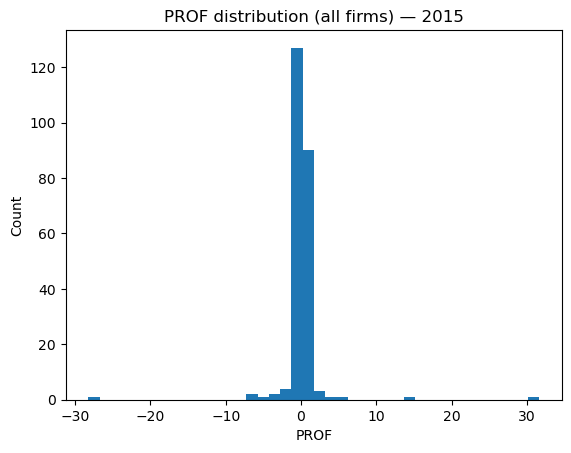

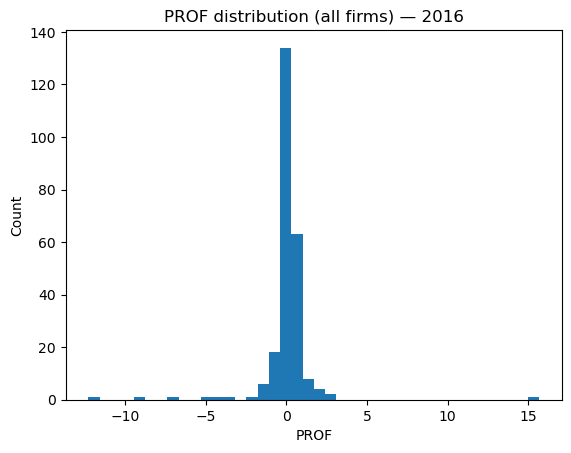

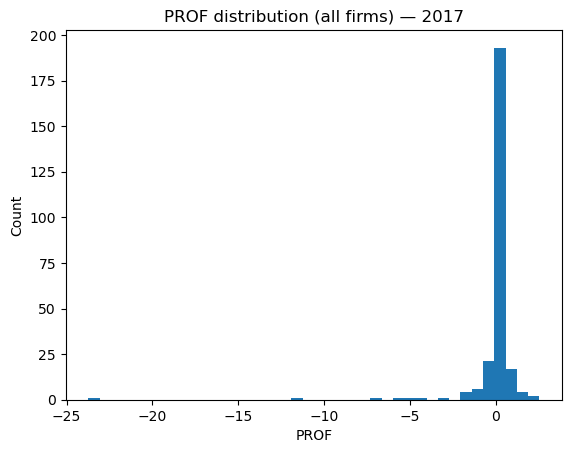

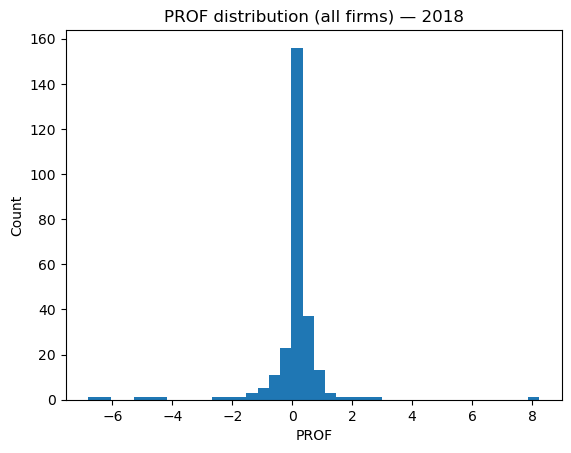

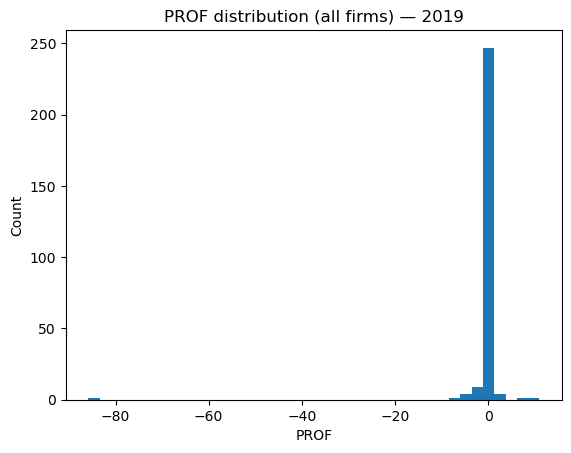

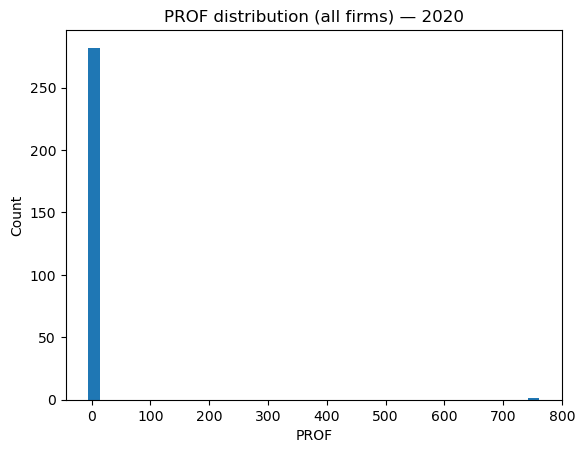

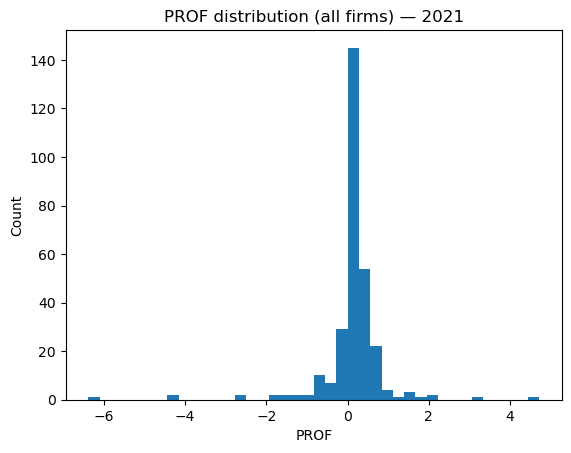

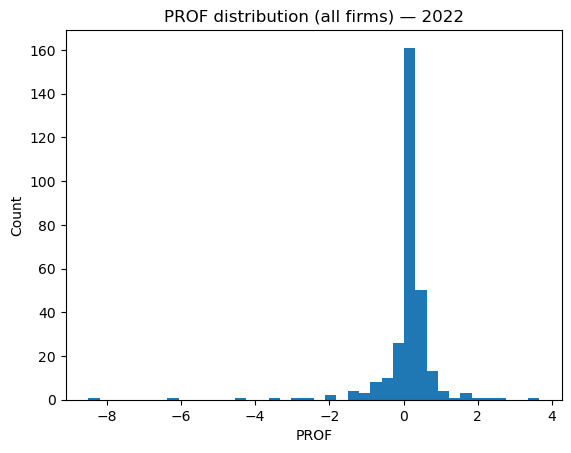

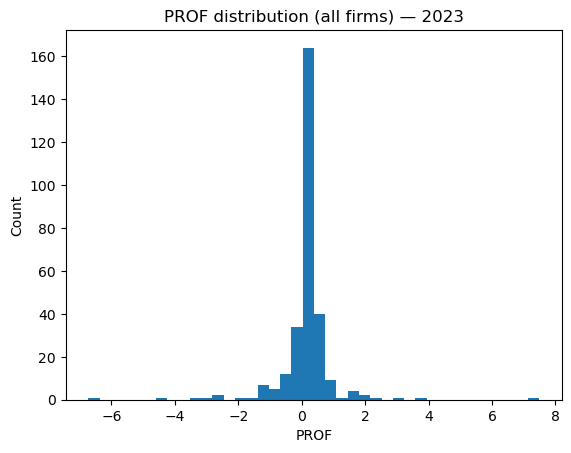

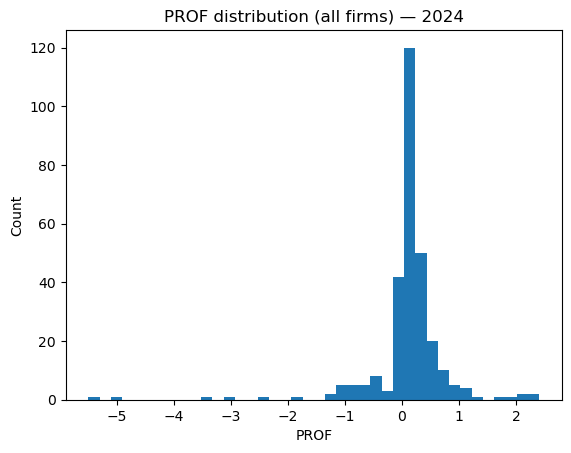

In [7]:

# ---------- Plot 1: PROF distribution each year (ALL firms) ----------
years = sorted(panel["Year"].unique())
years_to_plot = years[-10:] if len(years) > 10 else years  # last 10 years if many

for y in years_to_plot:
    vals = panel.loc[panel["Year"] == y, "PROF"].replace([np.inf, -np.inf], np.nan).dropna()
    plt.figure()
    plt.hist(vals, bins=40)
    plt.title(f"PROF distribution (all firms) — {y}")
    plt.xlabel("PROF")
    plt.ylabel("Count")
    plt.show()


/var/folders/6l/ncl3jvl12ks8dlc1p950qzsh0000gn/T/ipykernel_56361/335121514.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mom = panel.groupby("Year").apply(moments).reset_index()


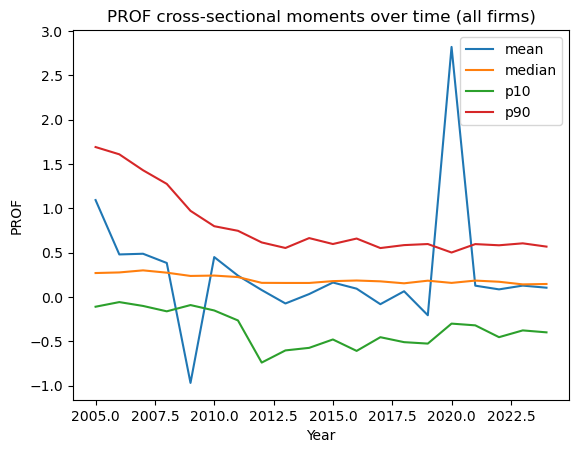

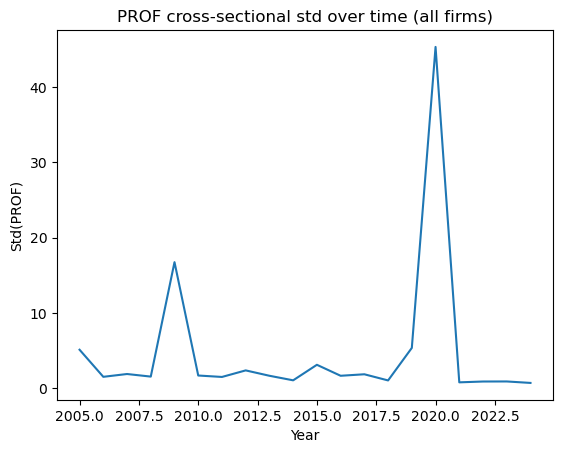

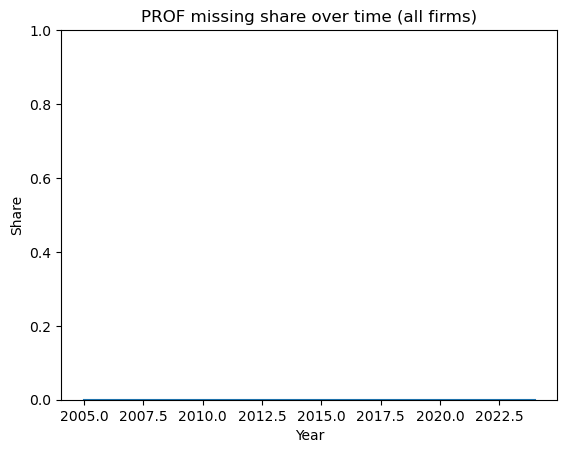

In [8]:
# ---------- Plot 2: Cross-sectional moments over time (ALL firms) ----------
def moments(g):
    s = g["PROF"].replace([np.inf, -np.inf], np.nan)
    return pd.Series({
        "mean": s.mean(),
        "median": s.median(),
        "p10": s.quantile(0.10),
        "p90": s.quantile(0.90),
        "std": s.std(),
        "n": s.notna().sum(),
        "nan_share": 1 - s.notna().mean(),
    })

mom = panel.groupby("Year").apply(moments).reset_index()

plt.figure()
plt.plot(mom["Year"], mom["mean"], label="mean")
plt.plot(mom["Year"], mom["median"], label="median")
plt.plot(mom["Year"], mom["p10"], label="p10")
plt.plot(mom["Year"], mom["p90"], label="p90")
plt.title("PROF cross-sectional moments over time (all firms)")
plt.xlabel("Year")
plt.ylabel("PROF")
plt.legend()
plt.show()

plt.figure()
plt.plot(mom["Year"], mom["std"])
plt.title("PROF cross-sectional std over time (all firms)")
plt.xlabel("Year")
plt.ylabel("Std(PROF)")
plt.show()

plt.figure()
plt.plot(mom["Year"], mom["nan_share"])
plt.title("PROF missing share over time (all firms)")
plt.xlabel("Year")
plt.ylabel("Share")
plt.ylim(0, 1)
plt.show()


In [ ]:
# ---------- Plot 3: Component diagnostics over time (ALL firms, medians) ----------
components = ["REVT", "COGS", "XSGA_COMPONENTS", "XRD", "XINT", "BE", "MIB"]
missing_components = [c for c in components if c not in panel.columns]
if missing_components:
    raise ValueError(f"Missing component columns in panel: {missing_components}")

comp_median = panel.groupby("Year")[components].median(numeric_only=True).reset_index()

for c in components:
    plt.figure()
    plt.plot(comp_median["Year"], comp_median[c])
    plt.title(f"Median {c} over time (all firms)")
    plt.xlabel("Year")
    plt.ylabel(c)
    plt.show()
